In [4]:
# SHLOK VIJ
# PRN: 23070521143

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1, l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
data = pd.read_csv("/content/sample_data/california_housing_train.csv")

print("Dataset Shape:", data.shape)
print(data.head())

# Separate features and target
X = data.drop("median_house_value", axis=1) # Updated target column name for California housing dataset
y = data["median_house_value"]

# Keep numerical features
X = X.select_dtypes(include=np.number)

# Handle missing values by filling with the mean (a simple approach for demonstration)
X = X.fillna(X.mean())

print("\nNumber of Features:", X.shape[1])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create neural network
def create_model(regularizer=None, use_dropout=False, learning_rate=0.0001):

    model = Sequential()

    # Hidden Layer 1
    model.add(Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizer,
        input_shape=(X_train.shape[1],)
    ))

    # Dropout 30%
    if use_dropout:
        model.add(Dropout(0.3))

    # Hidden Layer 2
    model.add(Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizer
    ))

    # Dropout 30%
    if use_dropout:
        model.add(Dropout(0.3))

    # Hidden Layer 3
    model.add(Dense(
        16,
        activation="relu",
        kernel_regularizer=regularizer
    ))

    # Output Layer
    model.add(Dense(1))

    # Compile model
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

# Baseline model
print("\nBASELINE MODEL")
baseline_model = create_model()
baseline_model.summary()

# L1 Regularization model
print("\nL1 REGULARIZATION MODEL")
l1_model = create_model(
    regularizer=l1(0.001)
)
l1_model.summary()

# L2 Regularization model
print("\nL2 REGULARIZATION MODEL")
l2_model = create_model(
    regularizer=l2(0.001)
)
l2_model.summary()

# Dropout model
print("\nDROPOUT MODEL")
dropout_model = create_model(
    use_dropout=True
)
dropout_model.summary()

# Store models
models = {
    "Baseline": baseline_model,
    "L1": l1_model,
    "L2": l2_model,
    "Dropout": dropout_model
}

histories = {}

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity.
    verbose=1 # Log messages when training stops
)

# Train all models
for name, model in models.items():

    print("\nTraining:", name)

    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        verbose=1,
        callbacks=[early_stopping]
    )
    histories[name] = history

Dataset Shape: (17000, 9)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  

Number of Features: 8
Training Samples: 13600
Testing Samples: 3400

BASELINE MODEL


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


Training: Baseline
Epoch 1/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 56411840512.0000 - mae: 207176.2344 - val_loss: 54829649920.0000 - val_mae: 204827.6719
Epoch 2/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56407576576.0000 - mae: 207166.0312 - val_loss: 54820696064.0000 - val_mae: 204806.2188
Epoch 3/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56386977792.0000 - mae: 207118.3594 - val_loss: 54786818048.0000 - val_mae: 204726.6562
Epoch 4/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56329138176.0000 - mae: 206985.5781 - val_loss: 54707064832.0000 - val_mae: 204540.9375
Epoch 5/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56211451904.0000 - mae: 206718.2188 - val_loss: 54559117312.0000 - val_mae: 204198.7969
Epoch 6/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56011186176.0000 - mae: 206264.9219 - val_loss: 54322823168.0000 - val_mae: 203653.4531
Epoch 7/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 55708733440.0000 - mae: 205581.3

### Training History Analysis

Let's visualize the training and validation loss and Mean Absolute Error (MAE) for each model. This will help us understand how each model learned over epochs and whether there are signs of overfitting or underfitting.

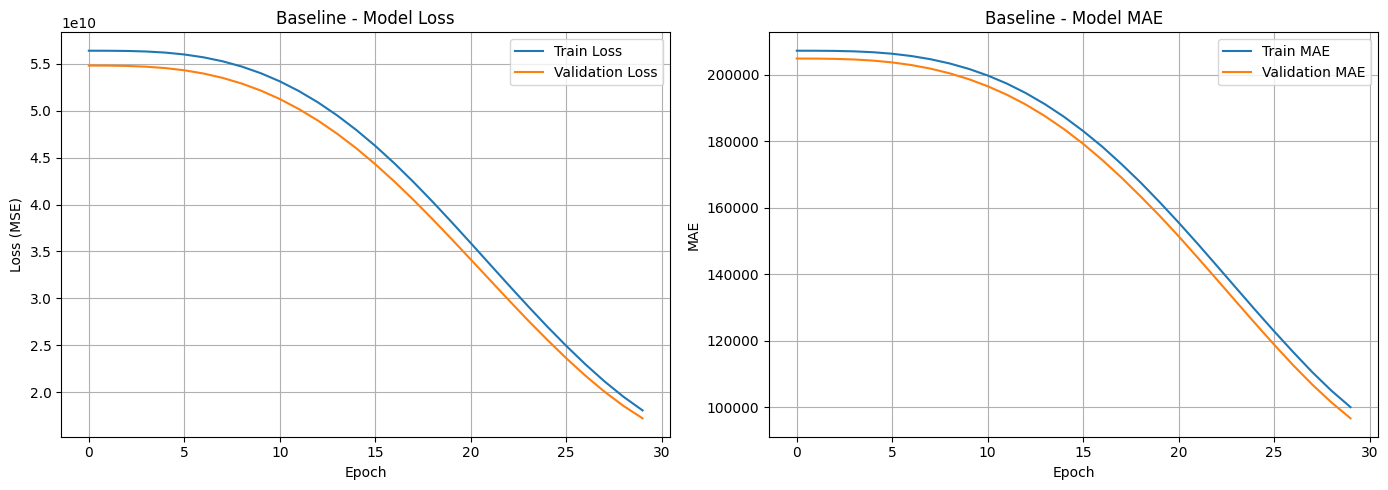

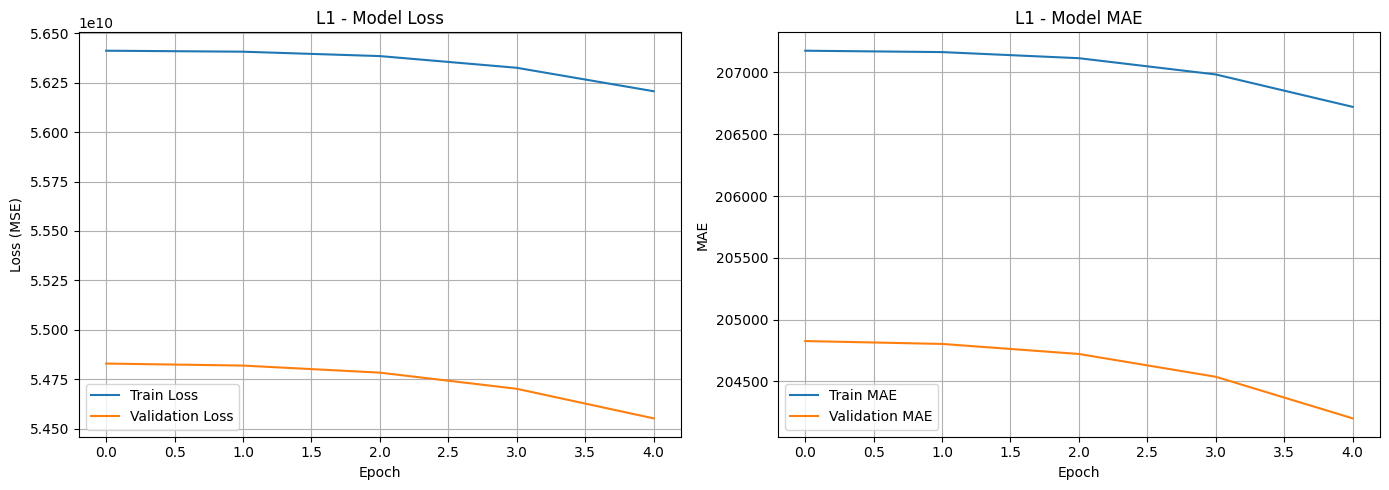

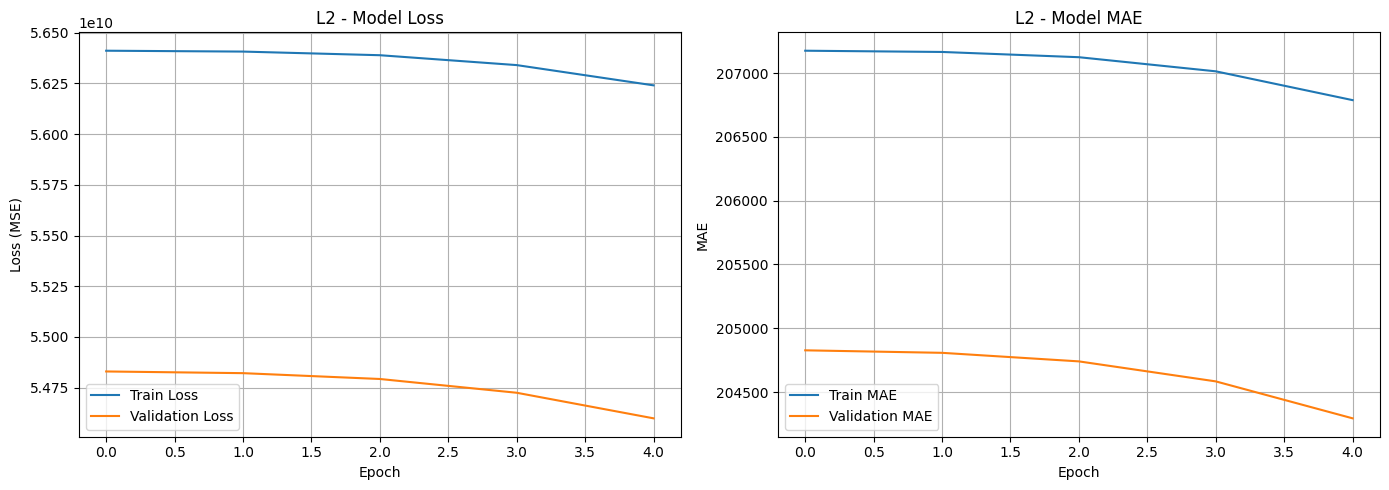

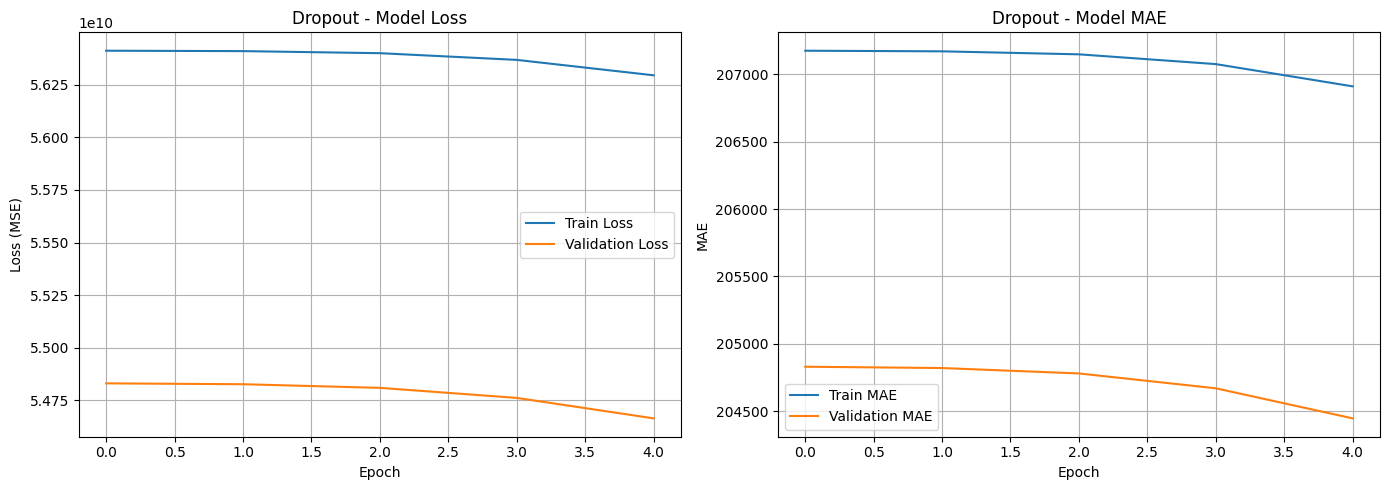

In [5]:
def plot_history(history, model_name):
    plt.figure(figsize=(14, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title(f'{model_name} - Model MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

for name, history in histories.items():
    plot_history(history, name)

In [6]:
results = {}

for name, model in models.items():
    print(f'\nEvaluating {name} Model:')
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

    print(f'  MSE: {mse:.2f}')
    print(f'  MAE: {mae:.2f}')
    print(f'  R-squared: {r2:.2f}')

# Display a summary of all model results
results_df = pd.DataFrame(results).T
print('\n--- Model Performance Summary ---')
display(results_df.sort_values(by='MAE'))


Evaluating Baseline Model:
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  MSE: 17535460251.29
  MAE: 99083.43
  R-squared: -0.27

Evaluating L1 Model:
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  MSE: 57739966530.13
  MAE: 209669.32
  R-squared: -3.19

Evaluating L2 Model:
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  MSE: 57740076259.17
  MAE: 209669.49
  R-squared: -3.19

Evaluating Dropout Model:
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  MSE: 57741047640.77
  MAE: 209671.68
  R-squared: -3.19

--- Model Performance Summary ---


,MSE,MAE,R2
Baseline,1.753546e+10,99083.430683,-0.272636
L1,5.773997e+10,209669.317776,-3.190478
L2,5.774008e+10,209669.487392,-3.190486
Dropout,5.774105e+10,209671.680732,-3.190557
